# Project 5 — Attention (Capstone)

In Project 4 you noticed something sharp: the encoder–decoder *could* model coupled, autoregressive outputs, but on that smooth periodic signal it never actually **beat** the humble Direct model. The reason was the data — nothing needed the extra machinery.

So this project uses a task **engineered to break the fixed-vector bottleneck**, so attention's advantage is finally *undeniable*.

## The task: the *echo* problem
Each input window is mostly flat noise, but somewhere inside it — at a **random, variable position `p`** — we hide a distinctive **motif** (a little random-frequency wave). The target is simply: **reproduce that motif**.

To succeed, a model must (1) *find* the motif (its position `p` changes every example) and (2) *copy its shape*. This is exactly the setting where a single fixed summary vector fails — it would have to cram both *where* the motif is **and** its full shape into one vector — while **attention** can just look back and point at it.

## The bottleneck attention removes
Vanilla seq2seq hands the decoder **one** vector (the encoder's final hidden state). Attention instead lets the decoder look at **all** encoder hidden states $h_1,\dots,h_L$ and, at each output step, compute a **weighted read**:

$$\text{score}_j = q \cdot k_j, \qquad \alpha_j = \frac{e^{\text{score}_j}}{\sum_i e^{\text{score}_i}}, \qquad \text{context} = \sum_{j=1}^{L} \alpha_j\, v_j$$

where the **query** $q$ is the decoder's current state, and the **keys/values** $k_j, v_j$ are the encoder states. The $\alpha_j$ are interpretable attention weights — and in Step 7 you'll **see** the decoder point straight at the motif.

**🛠️ Your one new mechanism to implement:** the three lines of dot-product attention (score → softmax → context). Everything else is wired for you.

## Step 1 — Imports & device
*(provided)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 2 — Generate the echo dataset
*(provided)*

Each example: flat background noise, plus a random-frequency **motif** of length `HORIZON` inserted at a **random position `p`**. The target is the motif itself. We keep the true `p` only so we can check where attention *should* look.

X_train: (4000, 80, 1) | Y_train: (4000, 20, 1)


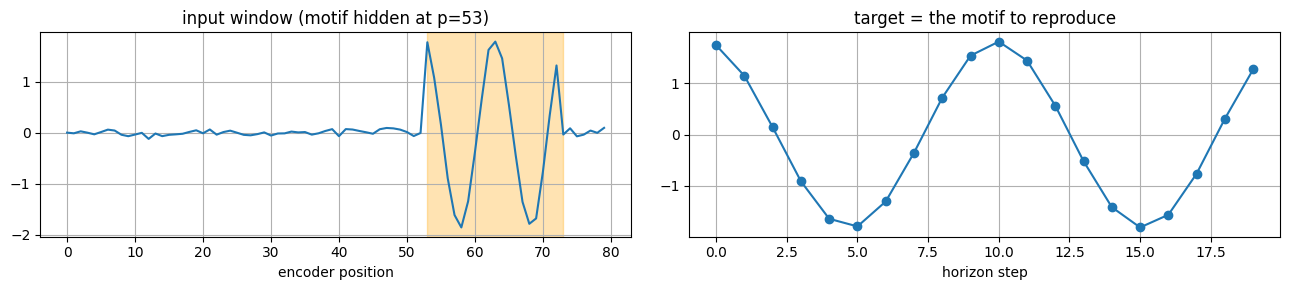

In [2]:
ENC_LEN = 80     # input window length
HORIZON = 20     # motif length = forecast length

def make_echo(n, enc_len, horizon, rng):
    X = rng.normal(0, 0.05, size=(n, enc_len)).astype(np.float32)   # flat background
    Y = np.zeros((n, horizon), dtype=np.float32)
    pos = np.zeros(n, dtype=np.int64)
    tt = np.arange(horizon)
    for i in range(n):
        p = int(rng.integers(0, enc_len - horizon))       # variable motif position
        freq  = rng.uniform(0.5, 2.0)                      # random shape ...
        phase = rng.uniform(0, 2 * np.pi)
        amp   = rng.uniform(1.5, 2.5)
        motif = (amp * np.sin(2 * np.pi * freq * tt / horizon + phase)).astype(np.float32)
        X[i, p:p + horizon] += motif                      # hide motif in the window
        Y[i] = motif                                      # target = reproduce it
        pos[i] = p
    return X[..., None], Y[..., None], pos                # X:(n,L,1) Y:(n,H,1)

rng = np.random.default_rng(0)
X_train, Y_train, pos_train = make_echo(4000, ENC_LEN, HORIZON, rng)
X_test,  Y_test,  pos_test  = make_echo(800,  ENC_LEN, HORIZON, rng)
print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)

# visualize one example
i = 0
p = pos_train[i]
fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(X_train[i, :, 0]); ax[0].axvspan(p, p + HORIZON, color="orange", alpha=0.3)
ax[0].set_title(f"input window (motif hidden at p={p})"); ax[0].set_xlabel("encoder position"); ax[0].grid(True)
ax[1].plot(Y_train[i, :, 0], "-o"); ax[1].set_title("target = the motif to reproduce")
ax[1].set_xlabel("horizon step"); ax[1].grid(True)
plt.tight_layout(); plt.show()

## Step 3 — Dataset + DataLoader
*(provided)*

In [3]:
class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dl = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
test_dl  = DataLoader(SeqDataset(X_test,  Y_test),  batch_size=256, shuffle=False)

xb, yb = next(iter(train_dl))
print("batch X:", xb.shape, "| batch Y:", yb.shape)

batch X: torch.Size([64, 80, 1]) | batch Y: torch.Size([64, 20, 1])


## Step 4 — The two baselines (Direct & vanilla Seq2Seq)
*(provided — both are the models you already built in Project 4)*

For a clean 3-way comparison, both baselines and the attention model here run **free-running** (each feeds its own previous prediction — no teacher forcing), so the *only* thing that differs is the architecture. `train_model` and `evaluate` work for all three.

In [4]:
class DirectForecaster(nn.Module):
    def __init__(self, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)
    def forward(self, x):
        _, h = self.rnn(x)
        return self.fc(h[-1]).unsqueeze(-1)          # (batch, horizon, 1)


class Seq2Seq(nn.Module):
    def __init__(self, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.horizon = horizon
        self.encoder = nn.GRU(1, hidden_size, batch_first=True)
        self.decoder = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, h = self.encoder(x)                       # single summary vector (the bottleneck)
        dec_in = torch.zeros(x.size(0), 1, 1, device=x.device)
        outs = []
        for _ in range(self.horizon):
            dec_out, h = self.decoder(dec_in, h)
            pred = self.fc(dec_out.squeeze(1))       # (batch, 1)
            outs.append(pred.unsqueeze(1))
            dec_in = pred.unsqueeze(1)
        return torch.cat(outs, dim=1)                # (batch, horizon, 1)

In [5]:
def train_model(model, epochs=40, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        losses = []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:2d} | train MSE {np.mean(losses):.5f}")

@torch.no_grad()
def evaluate(model):
    model.eval()
    preds = []
    for xb, yb in test_dl:
        preds.append(model(xb.to(device)).cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    return preds, np.mean((preds - Y_test) ** 2)

print("--- Direct ---")
direct = DirectForecaster().to(device); train_model(direct)
_, mse_direct = evaluate(direct)

print("--- Seq2Seq (no attention) ---")
seq2seq = Seq2Seq().to(device); train_model(seq2seq)
_, mse_seq2seq = evaluate(seq2seq)

print(f"\nDirect   test MSE: {mse_direct:.5f}")
print(f"Seq2Seq  test MSE: {mse_seq2seq:.5f}")

--- Direct ---
epoch 10 | train MSE 0.85665
epoch 20 | train MSE 0.19778
epoch 30 | train MSE 0.10592
epoch 40 | train MSE 0.06846
--- Seq2Seq (no attention) ---
epoch 10 | train MSE 1.20648
epoch 20 | train MSE 0.36594
epoch 30 | train MSE 0.16044
epoch 40 | train MSE 0.11776

Direct   test MSE: 0.06695
Seq2Seq  test MSE: 0.11663


## Step 5 — 🛠️ Implement attention, then the attentional decoder

**Dot-product attention** (parameter-free — the cleanest version). Given a **query** `q` (the decoder's current state, shape `(batch, hidden)`) and **keys** `K` (all encoder states, shape `(batch, enc_len, hidden)`):

1. **scores** — how well does the query match each encoder position? $\text{score}_j = q \cdot k_j$. Shape `(batch, enc_len)`.
2. **weights** — softmax the scores over the `enc_len` axis so they sum to 1. Shape `(batch, enc_len)`.
3. **context** — the weighted sum of the encoder states, $\sum_j \alpha_j k_j$. Shape `(batch, hidden)`.

**Batched-matrix hints:** `torch.bmm(K, q.unsqueeze(-1)).squeeze(-1)` gives the scores; `torch.bmm(weights.unsqueeze(1), K).squeeze(1)` gives the context.

**🛠️ TODO:** fill the three lines in `Attention.forward`. The `AttnSeq2Seq` decoder below is already wired to use it and to stash the weights for the Step 7 heatmap.

In [12]:
class Attention(nn.Module):
    """Parameter-free dot-product attention."""
    def forward(self, query, keys):
        scores = torch.bmm(keys, query.unsqueeze(-1)).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)

        # query: (batch, hidden)   keys: (batch, enc_len, hidden)
        # 🛠️ TODO (1): scores  = q . k_j            -> (batch, enc_len)
        # 🛠️ TODO (2): weights = softmax over enc_len -> (batch, enc_len)
        # 🛠️ TODO (3): context = sum_j weights_j * k_j -> (batch, hidden)
        # raise NotImplementedError
        return context, weights


class AttnSeq2Seq(nn.Module):
    def __init__(self, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.horizon = horizon
        self.encoder = nn.GRU(1, hidden_size, batch_first=True)
        self.decoder = nn.GRU(1, hidden_size, batch_first=True)
        self.attn = Attention()
        self.fc = nn.Linear(2 * hidden_size, 1)      # combines decoder state + context

    def forward(self, x):
        enc_out, h = self.encoder(x)                 # enc_out: (batch, enc_len, hidden) = all keys
        dec_in = torch.zeros(x.size(0), 1, 1, device=x.device)
        outs, attns = [], []
        for _ in range(self.horizon):
            dec_out, h = self.decoder(dec_in, h)     # (batch, 1, hidden)
            query = dec_out.squeeze(1)               # (batch, hidden)
            context, weights = self.attn(query, enc_out)
            combined = torch.cat([query, context], dim=-1)   # (batch, 2*hidden)
            pred = self.fc(combined)                 # (batch, 1)
            outs.append(pred.unsqueeze(1))
            attns.append(weights.unsqueeze(1))       # (batch, 1, enc_len)
            dec_in = pred.unsqueeze(1)
        self.last_attn = torch.cat(attns, dim=1)     # (batch, horizon, enc_len) — for the heatmap
        return torch.cat(outs, dim=1)                # (batch, horizon, 1)

## Step 6 — Train the attention model
*(provided)*

In [15]:
print("--- Seq2Seq + Attention ---")
attn_model = AttnSeq2Seq().to(device); train_model(attn_model)
_, mse_attn = evaluate(attn_model)

print(f"\nDirect              test MSE: {mse_direct:.5f}")
print(f"Seq2Seq (no attn)   test MSE: {mse_seq2seq:.5f}")
print(f"Seq2Seq + Attention test MSE: {mse_attn:.5f}")

--- Seq2Seq + Attention ---
epoch 10 | train MSE 0.26153
epoch 20 | train MSE 0.10905
epoch 30 | train MSE 0.06639
epoch 40 | train MSE 0.04440

Direct              test MSE: 0.06695
Seq2Seq (no attn)   test MSE: 0.11663
Seq2Seq + Attention test MSE: 0.04066


## Step 7 — The payoff: bake-off + the attention heatmap
*(provided)*

The bar chart should show attention winning **decisively** this time. The heatmap is the real prize: each row is a decoder step, each column an encoder position, and the brightness is the attention weight. If attention learned the task, you'll see a **bright diagonal band starting at the true motif position `p`** — the decoder literally pointing at the motif and sweeping across it as it reproduces the shape.

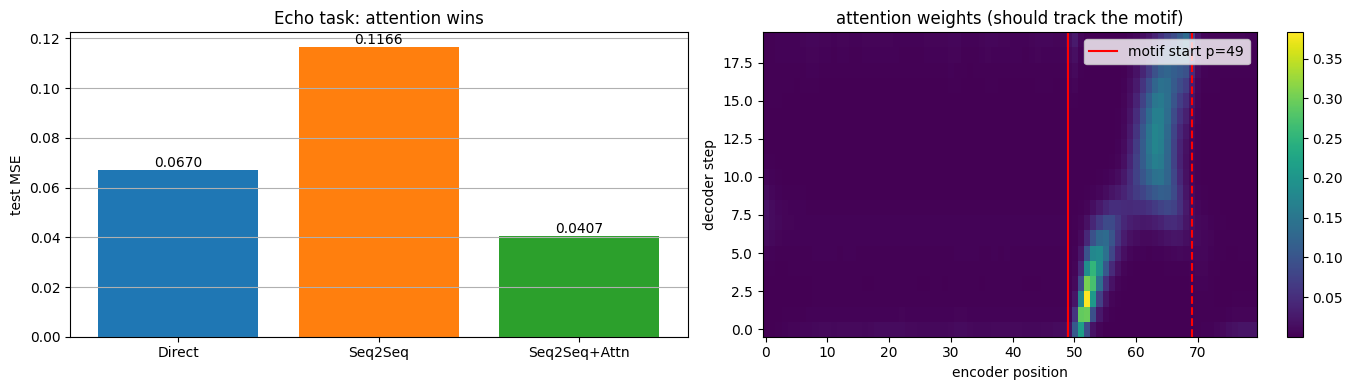

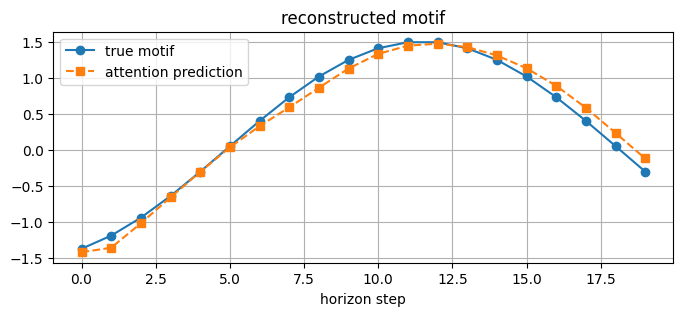

In [16]:
# (a) bake-off bar chart
names = ["Direct", "Seq2Seq", "Seq2Seq+Attn"]
vals  = [mse_direct, mse_seq2seq, mse_attn]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(names, vals, color=["tab:blue", "tab:orange", "tab:green"])
ax[0].set_ylabel("test MSE"); ax[0].set_title("Echo task: attention wins"); ax[0].grid(True, axis="y")
for j, v in enumerate(vals):
    ax[0].text(j, v, f"{v:.4f}", ha="center", va="bottom")

# (b) attention heatmap for one test example
s = 0
p = pos_test[s]
attn_model.eval()
with torch.no_grad():
    _ = attn_model(torch.from_numpy(X_test[s:s+1]).to(device))
A = attn_model.last_attn[0].cpu().numpy()            # (horizon, enc_len)

im = ax[1].imshow(A, aspect="auto", origin="lower", cmap="viridis")
ax[1].axvline(p, color="red", lw=1.5, label=f"motif start p={p}")
ax[1].axvline(p + HORIZON, color="red", lw=1.5, ls="--")
ax[1].set_xlabel("encoder position"); ax[1].set_ylabel("decoder step")
ax[1].set_title("attention weights (should track the motif)"); ax[1].legend(loc="upper right")
fig.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

# (c) does the attention model actually reproduce the motif?
with torch.no_grad():
    yhat = attn_model(torch.from_numpy(X_test[s:s+1]).to(device)).cpu().numpy()[0, :, 0]
plt.figure(figsize=(8, 3))
plt.plot(Y_test[s, :, 0], "-o", label="true motif")
plt.plot(yhat, "--s", label="attention prediction")
plt.title("reconstructed motif"); plt.xlabel("horizon step"); plt.legend(); plt.grid(True); plt.show()

## Step 8 — 🛠️ Reflection

Answer after you run it:

1. **The gap you were missing.** By how much does attention beat Direct and vanilla Seq2Seq here? Contrast with Project 4, where Direct *won* — what changed about the *task* that flipped the result? 
> Project 4 was about continum prediction of a smoothly varying signal that can be encoded in a vector. But here it is required to known the signal along with its position. One vector is not enough to summarize this info.
2. **Read the heatmap.** Does the bright band start at the true `p` (red line)? Does it move diagonally as the decoder steps forward? What does that tell you the model is *doing*? 
>Actually the model is attending to successive motif positions.
3. **Why the bottleneck bit here but not in Project 4.** In your own words: why can one fixed hidden vector represent a smooth periodic signal's future, but *not* "a motif of random shape at a random position"?
> A single hidden vector can summarize a simple smooth signal. Here, the task is it must store where the motif is and what its exact waveform looks like!
1. **Keys vs values.** Here keys and values are the same tensor (`enc_out`). In general attention they can differ. Give one reason you might want a *separate* value projection.
> ... required to get deeper?
1. **Toward Transformers.** You just built attention *on top of* an RNN. A Transformer throws the RNN away and uses attention **only**. Based on what the heatmap shows the attention doing, why might attention alone be enough — and what would you lose (hint: does dot-product attention know the *order* of positions)? 
> required to get deeper
---
Fill in the `Attention.forward` TODO, run Steps 6–7, and send me your three MSEs + a description of the heatmap. That closes the ladder — from a vanilla RNN on a sine wave all the way to attention.